In [4]:
import pandas as pd

df = pd.read_csv("../data/Guest_Feedback.csv")

print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())

   Review_ID    Platform                                        Review_Text  \
0          1  MakeMyTrip  Tin shelter, hot/suffocating, flies, dirty was...   
1          2     Goibibo  Tin shelter, hot/suffocating, flies, dirty was...   
2          3      Google  Fantastic stay, nice rooms, stunning view, del...   
3          4      Google  Best in Makkumath, superb service/food, scenic...   
4          5      Google  Neat and clean rooms, awesome ambiance, budget...   

   Rating Sentiment        Theme  
0       1  Negative  Cleanliness  
1       2  Negative  Cleanliness  
2       5  Positive         Food  
3       5  Positive         Food  
4       5  Positive  Cleanliness  
(71, 6)
<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Review_ID    71 non-null     int64
 1   Platform     71 non-null     str  
 2   Review_Text  71 non-null     str  
 3   Rating     

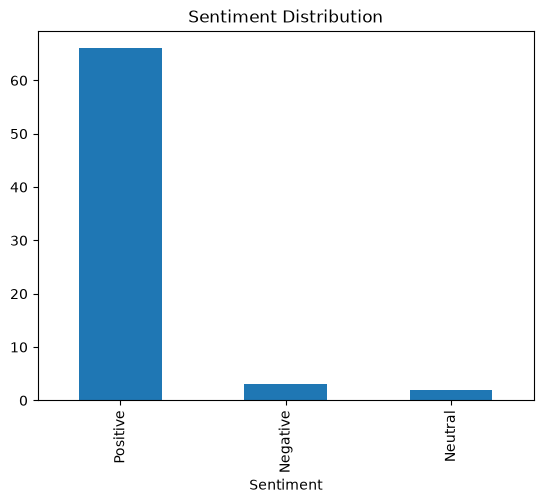

In [ ]:
##sentiment distribution

import matplotlib.pyplot as plt

df['Sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.show()

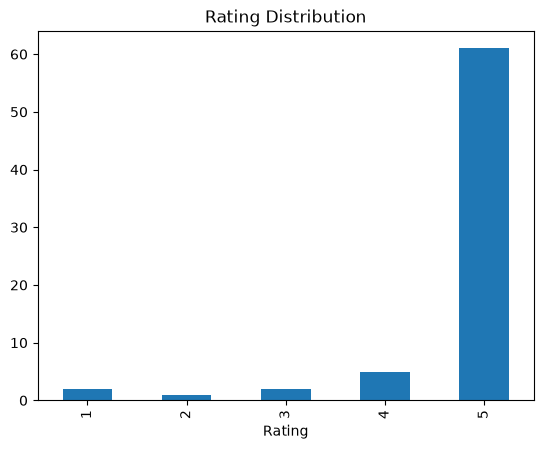

In [6]:
#rating distribution

df['Rating'].value_counts().sort_index().plot(kind='bar')

plt.title("Rating Distribution")
plt.show()

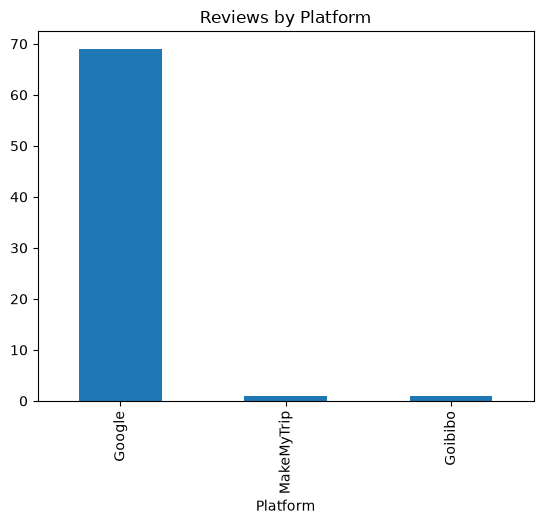

In [7]:
#platform distribution

df['Platform'].value_counts().plot(kind='bar')

plt.title("Reviews by Platform")
plt.show()

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [10]:
#features

df.head()
df.columns

X = df["Review_Text"]
y = df["Sentiment"]

print(X.shape)
print(y.shape)

(71,)
(71,)


In [11]:
#splitting data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 56
Testing samples: 15


In [16]:
#vectorizing reviews

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

#logistic regression model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_tfidf, y_train)

print("Model trained successfully")

#predictions

y_pred = model.predict(X_test_tfidf)

print(y_pred)

#accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

(56, 92)
(15, 92)
Model trained successfully
['Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive']
Accuracy: 0.9333333333333333


c:\Users\juhik\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\juhik\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\juhik\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         1
    Positive       0.93      1.00      0.97        14

    accuracy                           0.93        15
   macro avg       0.47      0.50      0.48        15
weighted avg       0.87      0.93      0.90        15



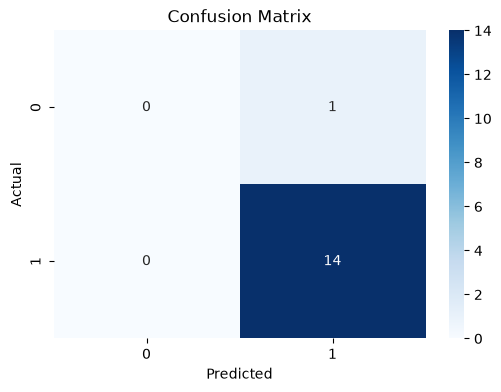

Review: Amazing experience and very friendly staff
Predicted Sentiment: Positive
--------------------------------------------------
Review: Room was dirty and service was poor
Predicted Sentiment: Positive
--------------------------------------------------
Review: The stay was okay, nothing special
Predicted Sentiment: Positive
--------------------------------------------------


In [18]:
#Classification report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

#Confusion matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#custom/sample review prediction

sample_reviews = [
    "Amazing experience and very friendly staff",
    "Room was dirty and service was poor",
    "The stay was okay, nothing special"
]

sample_tfidf = vectorizer.transform(sample_reviews)

predictions = model.predict(sample_tfidf)

for review, sentiment in zip(sample_reviews, predictions):
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment}")
    print("-" * 50)

In [19]:
import joblib

joblib.dump(model, "../models/sentiment_model.pkl")
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

print("Model saved successfully")

Model saved successfully
